# Dataset Preparation Visualization
This notebook visualizes samples from the prepared dataset including original images and extracted text.

In [1]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
import random

# Set up paths
base_path = Path('../test_data')
images_dir = base_path / 'images'
txts_dir = base_path / 'txts'
original_test_dir = base_path / 'test'

print(f"Images directory: {images_dir}")
print(f"Text files directory: {txts_dir}")
print(f"Original test directory: {original_test_dir}")

Images directory: ..\test_data\images
Text files directory: ..\test_data\txts
Original test directory: ..\test_data\test


## Load Sample Files

In [2]:
# Get all image files
image_files = sorted([f for f in images_dir.glob('*.jpg')])
print(f"Total images prepared: {len(image_files)}")
print(f"Sample files: {[f.name for f in image_files[:5]]}")

Total images prepared: 172
Sample files: ['eng_AF_004.jpg', 'eng_AF_007.jpg', 'eng_AF_010.jpg', 'eng_AF_011.jpg', 'eng_AF_016.jpg']


## Visualize Sample Dataset Entries (3 Random Samples)

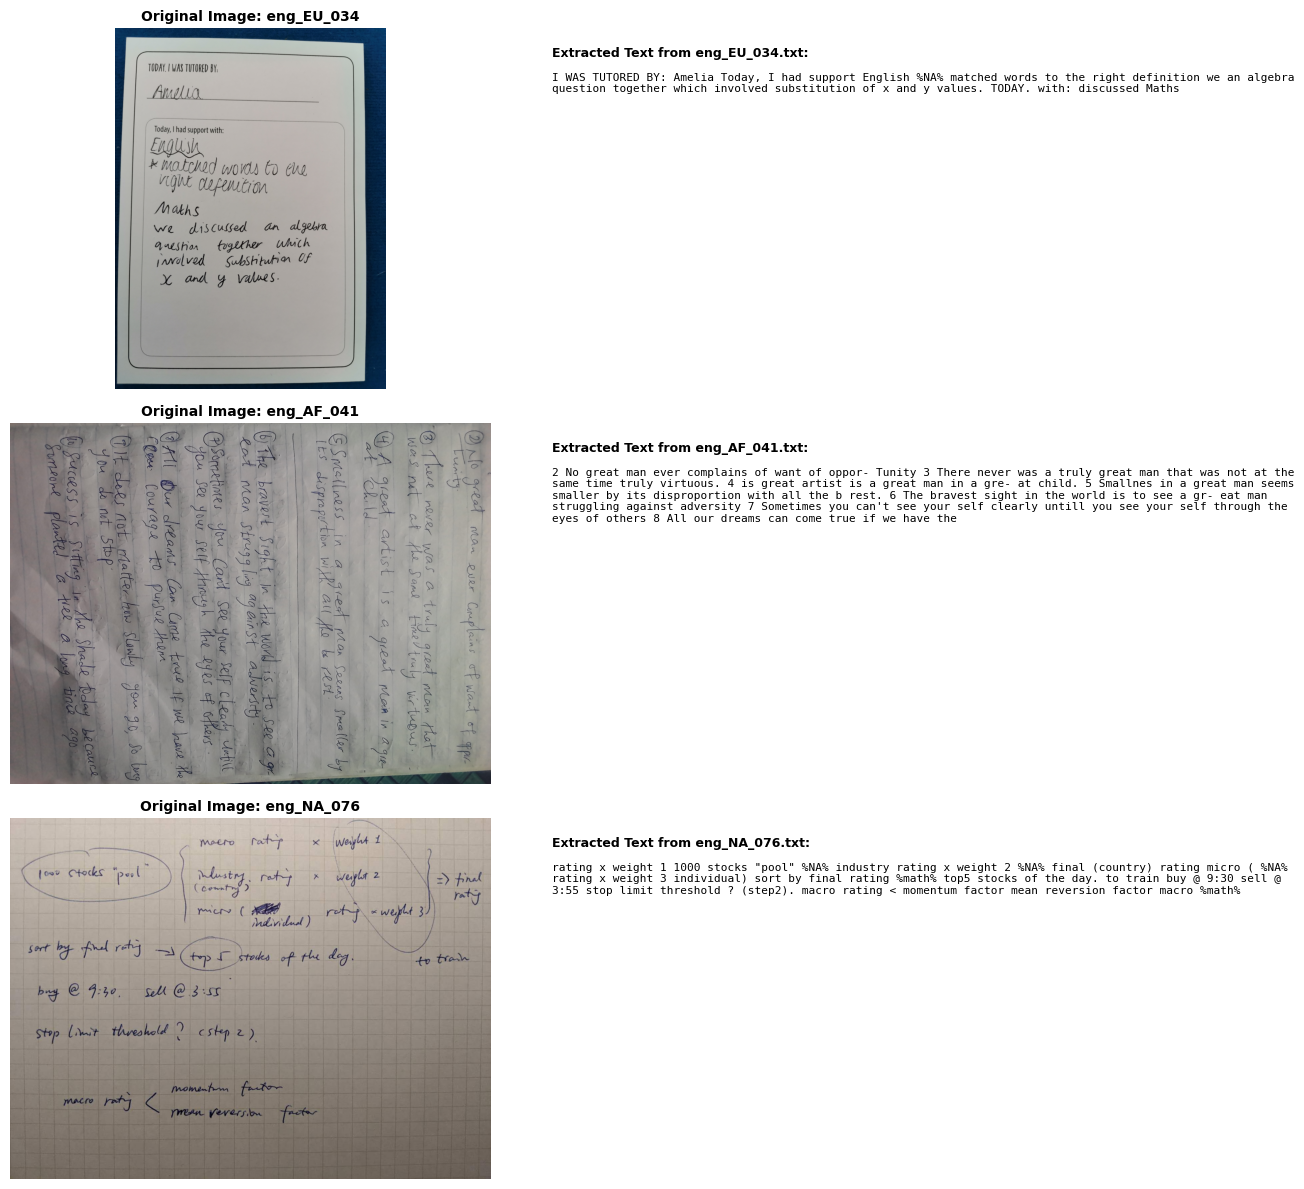


✅ Displayed 3 sample dataset entries


In [3]:
# Select 3 random samples
sample_files = random.sample(image_files, min(3, len(image_files)))

fig, axes = plt.subplots(len(sample_files), 2, figsize=(14, 12))
if len(sample_files) == 1:
    axes = axes.reshape(1, -1)

for idx, img_file in enumerate(sample_files):
    base_name = img_file.stem
    
    # Display original image
    img = Image.open(img_file)
    axes[idx, 0].imshow(img, cmap='gray')
    axes[idx, 0].set_title(f'Original Image: {base_name}', fontsize=10, fontweight='bold')
    axes[idx, 0].axis('off')
    
    # Display extracted text
    txt_file = txts_dir / f"{base_name}.txt"
    if txt_file.exists():
        with open(txt_file, 'r', encoding='utf-8') as f:
            text = f.read()
    else:
        text = "[Text file not found]"
    
    axes[idx, 1].text(0.05, 0.95, f"Extracted Text from {base_name}.txt:", 
                     transform=axes[idx, 1].transAxes, fontsize=9, fontweight='bold',
                     verticalalignment='top')
    axes[idx, 1].text(0.05, 0.88, text[:500], 
                     transform=axes[idx, 1].transAxes, fontsize=8,
                     verticalalignment='top', wrap=True, family='monospace')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✅ Displayed {len(sample_files)} sample dataset entries")

## Dataset Statistics

In [4]:
# Count prepared files
num_images = len(list(images_dir.glob('*')))
num_texts = len(list(txts_dir.glob('*.txt')))
num_pdfs = len(list((base_path / 'digitized_pdfs').glob('*.pdf')))

print("📊 Dataset Preparation Summary:")
print(f"  • Organized Images: {num_images}")
print(f"  • Extracted Text Files: {num_texts}")
print(f"  • Generated PDFs: {num_pdfs}")
print(f"\n✅ All data organized successfully!")

📊 Dataset Preparation Summary:
  • Organized Images: 172
  • Extracted Text Files: 172
  • Generated PDFs: 172

✅ All data organized successfully!


## Compare: Original JSON vs Extracted Text (Single Sample)

In [5]:
# Pick first available sample
sample_base = image_files[0].stem
original_json = original_test_dir / f"{sample_base}.json"
extracted_txt = txts_dir / f"{sample_base}.txt"

print(f"📋 Comparison for sample: {sample_base}\n")

# Show original JSON structure
if original_json.exists():
    with open(original_json, 'r', encoding='utf-8') as f:
        json_data = json.load(f)
    print(f"Original JSON annotations ({len(json_data)} entries):")
    for i, item in enumerate(json_data[:3]):
        if isinstance(item, dict):
            text = item.get('text', 'N/A')[:100]
            print(f"  [{i}] Text: {text}")
    if len(json_data) > 3:
        print(f"  ... and {len(json_data) - 3} more entries")

print(f"\nExtracted and concatenated text:")
if extracted_txt.exists():
    with open(extracted_txt, 'r', encoding='utf-8') as f:
        text = f.read()
    print(f"  {text[:200]}...")
    print(f"\n  Total length: {len(text)} characters")

📋 Comparison for sample: eng_AF_004

Original JSON annotations (53 entries):
  [0] Text: what
  [1] Text: I
  [2] Text: hope
  ... and 50 more entries

Extracted and concatenated text:
  what I hope to achieve during this period of memtorship %math% improve my and writing %math% Learn how to run a business things i need to do Have a writing time and day setaside Apply th free writing ...

  Total length: 286 characters
